In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
# from cmcrameri import cm

import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), "..", "utils"))
from dune_plot import apply_dune_style, dune_label
apply_dune_style()

In [6]:
# --- Geometry helpers (from Noise_Comparing_Spectra.ipynb) ---

def load_yaml(yaml_path):
    with open(yaml_path, "r") as f:
        return yaml.safe_load(f)


def get_sipm_rel_pos(lrs_geometry_yaml, adc, channel):
    tpc = -1
    det = -1
    for tpc_temp, det_map in lrs_geometry_yaml["det_adc"].items():
        for det_temp, adc_map in det_map.items():
            if adc_map == adc:
                if channel in lrs_geometry_yaml["det_chan"][tpc_temp][det_temp]:
                    tpc = tpc_temp
                    det = det_temp
    if tpc == -1 or det == -1:
        return -1, -1, -1, -1
    side = lrs_geometry_yaml["det_side"][det]
    vert_pos = lrs_geometry_yaml["ch_to_vert_bin"][adc][channel]
    return tpc, det, side, vert_pos


def get_sipm_abs_pos_array(lrs_geometry_yaml, tpc_offsets):
    sipm_channels = (
        [4,5,6,7,8,9] + [10,11,12,13,14,15] +
        [20,21,22,23,24,25] + [26,27,28,29,30,31] +
        [36,37,38,39,40,41] + [42,43,44,45,46,47] +
        [52,53,54,55,56,57] + [58,59,60,61,62,63]
    )
    tpc_offsets = np.asarray(tpc_offsets, dtype=float)
    sipm_abs_position = np.full((8, 64, 3), -1.0, dtype=float)
    n_sipm_centers = len(lrs_geometry_yaml["sipm_center"])
    half = n_sipm_centers // 2

    for adc in range(8):
        for channel in sipm_channels:
            tpc, det, side, vert_pos = get_sipm_rel_pos(lrs_geometry_yaml, adc, channel)
            if tpc == -1:
                continue
            tpc_channel = vert_pos + side * half
            sipm_center = np.asarray(lrs_geometry_yaml["sipm_center"][tpc_channel], dtype=float)
            tpc_center_offset = np.asarray(lrs_geometry_yaml["tpc_center_offset"][tpc], dtype=float)
            module_offset = tpc_offsets[tpc // 2]

            x_pos = module_offset[0] + tpc_center_offset[0]
            if tpc % 2 == 0:
                x_pos += sipm_center[0]
            else:
                x_pos -= sipm_center[0]
            y_pos = module_offset[1] + tpc_center_offset[1] + sipm_center[1]
            z_pos = module_offset[2] + tpc_center_offset[2] + sipm_center[2]

            sipm_abs_position[adc, channel] = [x_pos, y_pos, z_pos]

    return sipm_abs_position


def get_module_bounds(lrs_geometry_yaml, det_geometry_yaml):
    tpc_offsets = np.asarray(det_geometry_yaml["tpc_offsets"], dtype=float)
    drift_length = float(det_geometry_yaml["drift_length"])
    tpc0_offset = np.asarray(lrs_geometry_yaml["tpc_center_offset"][0], dtype=float)
    sipm_centers = np.array(list(lrs_geometry_yaml["sipm_center"].values()), dtype=float)
    y_rel = tpc0_offset[1] + sipm_centers[:, 1]
    z_rel = tpc0_offset[2] + sipm_centers[:, 2]
    ymin_rel, ymax_rel = np.min(y_rel), np.max(y_rel)
    zmin_rel, zmax_rel = np.min(z_rel), np.max(z_rel)
    bounds = []
    for module_center in tpc_offsets:
        cx, cy, cz = module_center
        bounds.append((
            (cx - drift_length) * 1.05, (cx + drift_length) * 1.05,
            (cy + ymin_rel) * 1.05, (cy + ymax_rel) * 1.05,
            (cz + zmin_rel) * 1.05, (cz + zmax_rel) * 1.05,
        ))
    return bounds


def draw_box_edges(ax, bounds, color="black", lw=1.2, ls="-"):
    xmin, xmax, ymin, ymax, zmin, zmax = bounds
    corners = np.array([
        [xmin, zmin, ymin], [xmax, zmin, ymin], [xmax, zmin, ymax], [xmin, zmin, ymax],
        [xmin, zmax, ymin], [xmax, zmax, ymin], [xmax, zmax, ymax], [xmin, zmax, ymax],
    ])
    edges = [
        (0,1),(1,2),(2,3),(3,0),(4,5),(5,6),(6,7),(7,4),(0,4),(1,5),(2,6),(3,7)
    ]
    for i, j in edges:
        ax.plot([corners[i,0],corners[j,0]], [corners[i,1],corners[j,1]],
                [corners[i,2],corners[j,2]], color=color, linewidth=lw, linestyle=ls)


def draw_cathode_plane(ax, bounds, x_cathode, color="dimgray", alpha=0.25, hatch=".."):
    _, _, ymin, ymax, zmin, zmax = bounds
    verts = [[[x_cathode,zmin,ymin],[x_cathode,zmin,ymax],
              [x_cathode,zmax,ymax],[x_cathode,zmax,ymin]]]
    plane = Poly3DCollection(verts, facecolor=color, edgecolor=color,
                             alpha=alpha, hatch=hatch, linewidths=0.8)
    ax.add_collection3d(plane)

In [7]:
# --- Load geometry and build SiPM position array ---
lrs = load_yaml("/global/cfs/cdirs/dune/users/ajwhite/2x2_LRS_DataAssess/Commissioning_Code/2x2_LRS_OperatingScripts/LowLevel_Commissioning/light_module_desc-5.0.1.yaml")
geo = load_yaml("/global/cfs/cdirs/dune/users/ajwhite/2x2_LRS_DataAssess/Commissioning_Code/2x2_LRS_OperatingScripts/LowLevel_Commissioning/2x2.yaml")

tpc_offsets = np.array([
    [33.5, 0., 33.5],
    [33.5, 0., -33.5],
    [-33.5, 0., 33.5],
    [-33.5, 0., -33.5],
])

sipm_channels = (
    [4,5,6,7,8,9] + [10,11,12,13,14,15] +
    [20,21,22,23,24,25] + [26,27,28,29,30,31] +
    [36,37,38,39,40,41] + [42,43,44,45,46,47] +
    [52,53,54,55,56,57] + [58,59,60,61,62,63]
)

sipm_abs_position = get_sipm_abs_pos_array(lrs, tpc_offsets)
sipm_abs_position_flat = sipm_abs_position[:, sipm_channels, :].reshape(-1, 3)

# --- Build mapping: flat SiPM index -> (tpc, det) ---
tpc_det_map = np.full((8, 64, 2), -1, dtype=int)  # (adc, channel) -> (tpc, det)
for adc in range(8):
    for channel in sipm_channels:
        tpc, det, _, _ = get_sipm_rel_pos(lrs, adc, channel)
        if tpc != -1:
            tpc_det_map[adc, channel] = [tpc, det]

tpc_det_flat = tpc_det_map[:, sipm_channels, :].reshape(-1, 2)
print(f"SiPM positions: {sipm_abs_position_flat.shape}, TPC/det map: {tpc_det_flat.shape}")

SiPM positions: (384, 3), TPC/det map: (384, 2)


In [8]:
# --- Load AmBe data and map activity onto SiPM channels ---
df = pd.read_csv("processed_AmBe_data_sum_hits.csv")
activity_det = df[df["R"] == "R1"].groupby(["tpc", "det"]).size().unstack(fill_value=0)
total = activity_det.values.sum()
activity_pct = 100 * activity_det / total

# Assign each SiPM channel the activity % of its parent (tpc, det)
activity_flat = np.zeros(len(tpc_det_flat))
for i, (tpc, det) in enumerate(tpc_det_flat):
    if tpc == -1:
        continue
    if tpc in activity_pct.index and det in activity_pct.columns:
        activity_flat[i] = activity_pct.loc[tpc, det]

print(f"Activity range: {activity_flat.min():.3f} – {activity_flat.max():.3f} %")

Activity range: 0.000 – 0.072 %


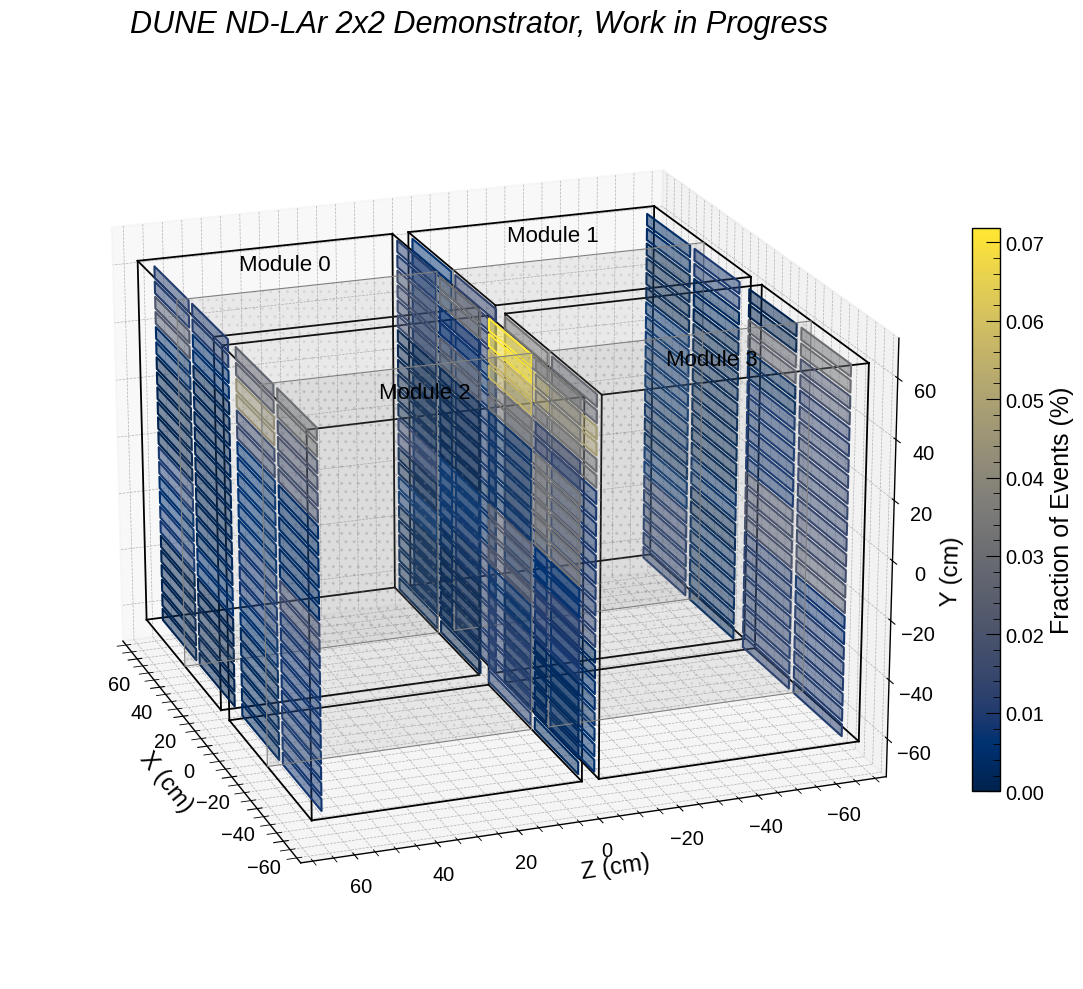

In [22]:
# --- 3D detector view of AmBe activity ---
vmin = 0
vmax = activity_flat.max()
norm = Normalize(vmin=vmin, vmax=vmax)
cmap = plt.get_cmap("cividis")

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

for result, value in zip(sipm_abs_position_flat, activity_flat):
    x, y, z_det = result
    if x > 60:
        x_offset = -29
    elif x > 0:
        x_offset = 29
    elif x < -60:
        x_offset = 29
    else:
        x_offset = -29
    corners = [
        [x, z_det, y - 2],
        [x + x_offset, z_det, y - 2],
        [x + x_offset, z_det, y + 2],
        [x, z_det, y + 2],
    ]
    color = cmap(norm(value))
    rect = Poly3DCollection([corners], color=color, alpha=0.5)
    ax.add_collection3d(rect)

# Draw module boxes and cathode planes
module_bounds = get_module_bounds(lrs, geo)
for i, bounds in enumerate(module_bounds):
    draw_box_edges(ax, bounds, color="black", lw=1.3)
    x_cathode = geo["tpc_offsets"][i][0]
    draw_cathode_plane(ax, bounds, x_cathode, color="gray", alpha=0.12, hatch="..")

# Module labels
for i, bounds in enumerate(module_bounds):
    xmin, xmax, ymin, ymax, zmin, zmax = bounds
    x_center = 0.5 * (xmin + xmax)
    x_text = xmax - 15 if x_center > 0 else xmin + 15
    ax.text(x_text, 0.5 * (zmin + zmax), ymax, f"Module {i}",
            fontsize=16, color="black", ha="center", va="center", zorder=500)

# Colorbar
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.6, pad=0.02)
cbar.set_label("Fraction of Events (%)", fontsize=18)

ax.view_init(elev=20, azim=160)
ax.set_xlabel("X (cm)")
ax.set_ylabel("Z (cm)")
ax.set_zlabel("Y (cm)")
ax.set_xlim(-70, 70)
ax.set_ylim(-70, 70)
ax.set_zlim(-70, 70)
ax.set_title("DUNE ND-LAr 2x2 Demonstrator, Work in Progress",
             fontsize=22, fontstyle="italic", color="black")
plt.tight_layout()
plt.show()